In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from sklearn.model_selection import (
    StratifiedKFold,
    TunedThresholdClassifierCV,
)

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
from src.features.preprocessing import build_preprocessor

In [4]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "telco_churn_clean.csv"
)

MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "split_manifest.csv"
)

SELECTED_MODEL_PATH = (
    PROJECT_ROOT
    / "reports"
    / "selected_model.json"
)

df = pd.read_csv(DATA_PATH)
manifest = pd.read_csv(MANIFEST_PATH)

with open(
    SELECTED_MODEL_PATH,
    "r"
) as file:
    selected_info = json.load(file)

print("Dataset:", df.shape)
print("Manifest:", manifest.shape)

print(
    "\nSelected model:",
    selected_info["model_family"]
)

print(
    "CV Average Precision:",
    round(
        selected_info[
            "cv_average_precision"
        ],
        4
    )
)

Dataset: (7043, 21)
Manifest: (7043, 3)

Selected model: XGBoost
CV Average Precision: 0.673


In [5]:
selected_info

{'model_family': 'XGBoost',
 'selection_metric': 'Average Precision',
 'cv_average_precision': 0.6729791877873071,
 'cv_f1': 0.636973697373231,
 'cv_recall': 0.7397993311036789,
 'cv_roc_auc': 0.8504445735630147,
 'best_parameters': {'classifier__subsample': 0.8,
  'classifier__scale_pos_weight': 2.0764,
  'classifier__reg_lambda': 1.0,
  'classifier__reg_alpha': 0.5,
  'classifier__n_estimators': 150,
  'classifier__min_child_weight': 1,
  'classifier__max_depth': 2,
  'classifier__learning_rate': 0.05,
  'classifier__colsample_bytree': 0.8}}

In [6]:
selected_family = (
    selected_info["model_family"]
)

selected_params = (
    selected_info["best_parameters"]
)

print("Family:", selected_family)

print("\nBest Parameters:")

for key, value in selected_params.items():
    print(f"{key}: {value}")

Family: XGBoost

Best Parameters:
classifier__subsample: 0.8
classifier__scale_pos_weight: 2.0764
classifier__reg_lambda: 1.0
classifier__reg_alpha: 0.5
classifier__n_estimators: 150
classifier__min_child_weight: 1
classifier__max_depth: 2
classifier__learning_rate: 0.05
classifier__colsample_bytree: 0.8


In [7]:
#Exact train/test split recreate

data = df.merge(
    manifest[
        ["customerID", "split"]
    ],
    on="customerID",
    how="left",
    validate="one_to_one"
)

train_data = data[
    data["split"] == "train"
].copy()

test_data = data[
    data["split"] == "test"
].copy()

print(
    "Training:",
    len(train_data)
)

print(
    "Testing:",
    len(test_data)
)

Training: 5634
Testing: 1409


In [8]:
# createTraining data
DROP_COLUMNS = [
    "customerID",
    "Churn",
    "split",
]

X_train = train_data.drop(
    columns=DROP_COLUMNS
)

y_train = train_data[
    "Churn"
].map({
    "No": 0,
    "Yes": 1,
})

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

X_train: (5634, 19)
y_train: (5634,)


In [9]:
#Selected model reconstruct function

def build_selected_pipeline(
    family,
    parameters
):

    if family == "Logistic Regression":

        classifier = LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=42,
        )

    elif family == "Random Forest":

        classifier = RandomForestClassifier(
            random_state=42,
            n_jobs=1,
        )

    elif family == "XGBoost":

        classifier = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=1,
        )

    else:
        raise ValueError(
            f"Unknown model family: {family}"
        )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                build_preprocessor()
            ),
            (
                "classifier",
                classifier
            ),
        ]
    )

    pipeline.set_params(
        **parameters
    )

    return pipeline

In [10]:
#create Selected pipeline
selected_pipeline = (
    build_selected_pipeline(
        selected_family,
        selected_params
    )
)

selected_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [11]:
#Threshold tuning CV define

threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [12]:
#Create Threshold tuner

threshold_model = (
    TunedThresholdClassifierCV(
        estimator=selected_pipeline,

        scoring="f1",

        response_method="predict_proba",

        thresholds=100,

        cv=threshold_cv,

        refit=True,

        n_jobs=-1,

        store_cv_results=True,
    )
)

In [13]:
#Threshold tune

threshold_model.fit(
    X_train,
    y_train
)


,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.","Pipeline(step...=None, ...))])"
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",'f1'
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'predict_proba'
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",True
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"best_score_ best_score_: float or NoneThe optimal score of the objective metric, evaluated at `best_threshold_`.",float64,0.6383


In [14]:
print(
    "Selected threshold:",
    round(
        threshold_model.best_threshold_,
        4
    )
)

print(
    "CV F1 at selected threshold:",
    round(
        threshold_model.best_score_,
        4
    )
)

Selected threshold: 0.4826
CV F1 at selected threshold: 0.6383


### Threshold tuning curve

In [15]:
threshold_results = pd.DataFrame({
    "Threshold":
        threshold_model.cv_results_[
            "thresholds"
        ],

    "F1":
        threshold_model.cv_results_[
            "scores"
        ],
})

threshold_results.head()

,Threshold,F1
0,0.010601,0.419414
1,0.020041,0.428266
2,0.029481,0.445254
3,0.038921,0.457907
4,0.048361,0.468091


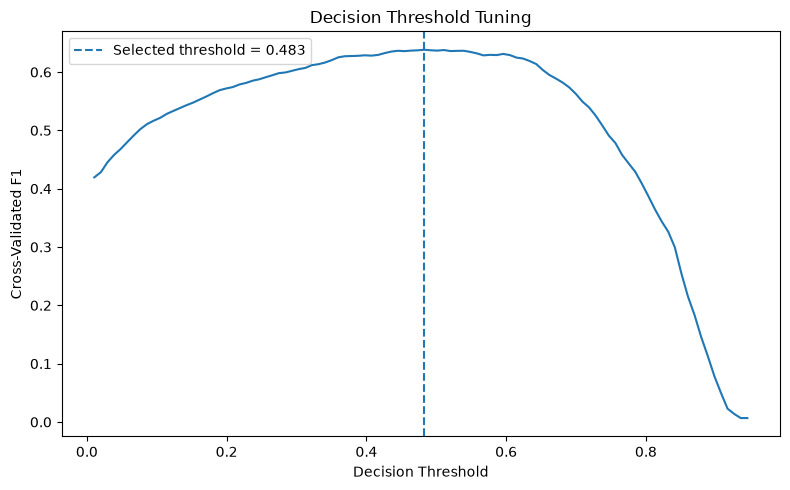

In [16]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"]
)

plt.axvline(
    threshold_model.best_threshold_,
    linestyle="--",
    label=(
        "Selected threshold = "
        f"{threshold_model.best_threshold_:.3f}"
    )
)

plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Cross-Validated F1"
)

plt.title(
    "Decision Threshold Tuning"
)

plt.legend()

plt.tight_layout()

FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    FIGURE_DIR
    / "threshold_tuning_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### TEST SET unlock

In [17]:
X_test = test_data.drop(
    columns=DROP_COLUMNS
)

y_test = test_data[
    "Churn"
].map({
    "No": 0,
    "Yes": 1,
})

id_test = test_data[
    "customerID"
].copy()

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

X_test: (1409, 19)
y_test: (1409,)


#### Test probabilities

In [18]:
test_probabilities = (
    threshold_model
    .predict_proba(
        X_test
    )[:, 1]
)

print(
    test_probabilities[:10]
)

[0.61683834 0.33707714 0.05748386 0.64473367 0.3200358  0.15662925
 0.8010304  0.74119717 0.03513177 0.6496255 ]


In [19]:
#Default 0.50 prediction
default_predictions = (
    test_probabilities >= 0.50
).astype(int)

In [20]:
#Tuned threshold prediction
tuned_predictions = (
    threshold_model.predict(
        X_test
    )
)

#### Evaluation function

In [21]:
def evaluate_predictions(
    name,
    y_true,
    y_pred,
    y_probability
):

    return {
        "Threshold Strategy": name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                y_probability
            ),

        "Average Precision":
            average_precision_score(
                y_true,
                y_probability
            ),
    }

#### Default vs Tuned final result

In [22]:
final_results = pd.DataFrame([
    evaluate_predictions(
        "Default Threshold (0.50)",
        y_test,
        default_predictions,
        test_probabilities
    ),

    evaluate_predictions(
        (
            "Tuned Threshold "
            f"({threshold_model.best_threshold_:.3f})"
        ),
        y_test,
        tuned_predictions,
        test_probabilities
    ),
])

final_results.round(4)

,Threshold Strategy,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Default Threshold (0.50),0.7736,0.7665,0.5542,0.7513,0.6379,0.8469,0.6628
1,Tuned Threshold (0.483),0.7608,0.7595,0.5350,0.7567,0.6268,0.8469,0.6628


In [23]:
final_results_percent = (
    final_results.copy()
)

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "Average Precision",
]

for column in metric_columns:
    final_results_percent[column] = (
        final_results_percent[column]
        .mul(100)
        .round(2)
    )

final_results_percent

,Threshold Strategy,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Default Threshold (0.50),77.36,76.65,55.42,75.13,63.79,84.69,66.28
1,Tuned Threshold (0.483),76.08,75.95,53.50,75.67,62.68,84.69,66.28


In [24]:
#Tuned classification report
print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

    No Churn     0.8966    0.7623    0.8240      1035
       Churn     0.5350    0.7567    0.6268       374

    accuracy                         0.7608      1409
   macro avg     0.7158    0.7595    0.7254      1409
weighted avg     0.8006    0.7608    0.7717      1409



In [25]:
#Confusion matrix numbers
cm = confusion_matrix(
    y_test,
    tuned_predictions
)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 789
False Positives: 246
False Negatives: 91
True Positives : 283


#### Tuned Confusion Matrix Plot

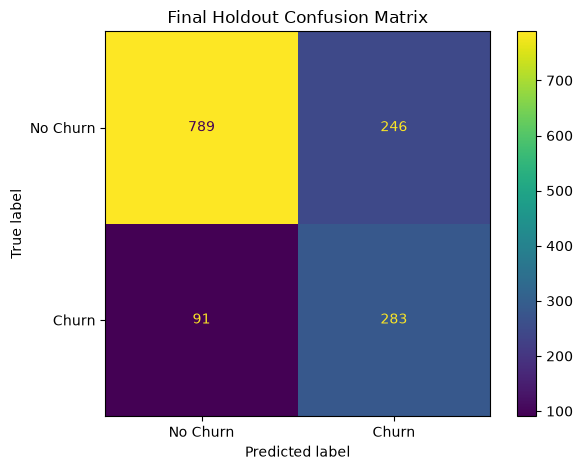

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

plt.title(
    "Final Holdout Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ROC Curve

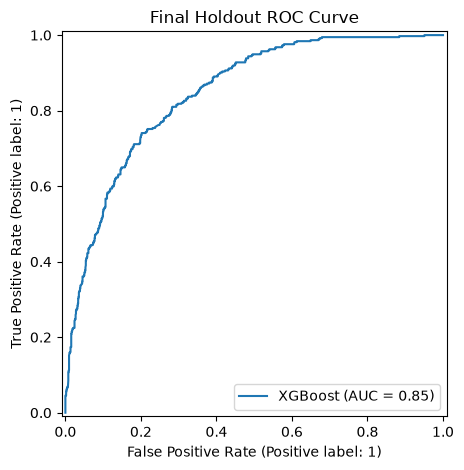

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_family
)

plt.title(
    "Final Holdout ROC Curve"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "final_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Precision-Recall Curve

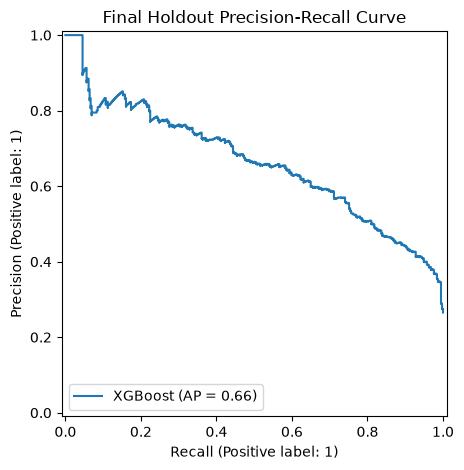

In [28]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name=selected_family
)

plt.title(
    "Final Holdout Precision-Recall Curve"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "final_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### CV vs Holdout generalization check

In [29]:
cv_ap = (
    selected_info[
        "cv_average_precision"
    ]
)

test_ap = average_precision_score(
    y_test,
    test_probabilities
)

cv_auc = (
    selected_info[
        "cv_roc_auc"
    ]
)

test_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print(
    "CV Average Precision:",
    round(cv_ap, 4)
)

print(
    "Test Average Precision:",
    round(test_ap, 4)
)

print(
    "AP Difference:",
    round(
        test_ap - cv_ap,
        4
    )
)

print()

print(
    "CV ROC-AUC:",
    round(cv_auc, 4)
)

print(
    "Test ROC-AUC:",
    round(test_auc, 4)
)

print(
    "AUC Difference:",
    round(
        test_auc - cv_auc,
        4
    )
)

CV Average Precision: 0.673
Test Average Precision: 0.6628
AP Difference: -0.0102

CV ROC-AUC: 0.8504
Test ROC-AUC: 0.8469
AUC Difference: -0.0035


In [30]:
#create Test prediction file

test_prediction_results = pd.DataFrame({
    "customerID":
        id_test.values,

    "Actual":
        y_test.values,

    "ChurnProbability":
        test_probabilities,

    "DefaultPrediction":
        default_predictions,

    "TunedPrediction":
        tuned_predictions,
})

test_prediction_results.head()

,customerID,Actual,ChurnProbability,DefaultPrediction,TunedPrediction
0,1452-KIOVK,0,0.616838,1,1
1,6713-OKOMC,0,0.337077,0,0
2,6388-TABGU,0,0.057484,0,0
3,5129-JLPIS,0,0.644734,1,1
4,4190-MFLUW,1,0.320036,0,0


In [31]:
#save
TEST_PREDICTION_PATH = (
    PROJECT_ROOT
    / "reports"
    / "final_test_predictions.csv"
)

test_prediction_results.to_csv(
    TEST_PREDICTION_PATH,
    index=False
)

#### Final metrics save, Threshold save


In [34]:
FINAL_METRICS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "final_holdout_metrics.csv"
)

final_results.to_csv(
    FINAL_METRICS_PATH,
    index=False
)

print(
    "Saved:",
    FINAL_METRICS_PATH
)


Saved: c:\AI_Projects\customer-churn-ml-system\reports\final_holdout_metrics.csv


In [35]:
THRESHOLD_PATH = (
    PROJECT_ROOT
    / "reports"
    / "decision_threshold.json"
)

threshold_information = {
    "model_family":
        selected_family,

    "threshold_selection_data":
        "training cross-validation only",

    "optimization_metric":
        "F1",

    "selected_threshold":
        float(
            threshold_model.best_threshold_
        ),

    "cv_f1_at_threshold":
        float(
            threshold_model.best_score_
        ),
}

with open(
    THRESHOLD_PATH,
    "w"
) as file:

    json.dump(
        threshold_information,
        file,
        indent=4
    )

print(
    "Threshold saved."
)

Threshold saved.


In [37]:
#sanity check
assert len(
    test_probabilities
) == 1409

assert len(
    tuned_predictions
) == 1409

assert (
    (test_probabilities >= 0)
    &
    (test_probabilities <= 1)
).all()

assert set(
    np.unique(tuned_predictions)
).issubset({
    0,
    1
})

print(
    "Final evaluation validation passed."
)

Final evaluation validation passed.
